In [27]:
%pylab inline 
import time

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [28]:
def g(u):
    M=1
    e=0.5
    return u-e*sin(u)-M

# Solution de référence: 
Comme on ne connait pas la solution exacte de notre problème. On calcule une solution aprochée (très précise) par la méthode de newthon prédéfinie dans le module optimize de scipy.

In [29]:
from scipy.optimize import newton 
x_ref=newton(g,1)
x_ref

1.4987011335178484

In [30]:
g(x_ref)

0.0

# Méthode de dichotomie 

In [31]:
def dichotomie(f,a,b,tol,Nmax):
    L=[]
    for i in range(Nmax):
        c=(a+b)/2
        L.append(c)
        if b-a <tol:
            return L
        if f(c)<0:
            a=c
        else :
            b=c

In [32]:
sol=dichotomie(g,0,3,1e-14,1000)
sol
print('Le nbr ditération est', len(sol) )

Le nbr ditération est 50


On peut tracer $|x_n-x_{ref}|$ en utilisant la fonction `abs` qui s’applique sur des tableaux de type array (donc il faut transformer la liste en array si on a généré la suite par une liste, on peut aussi directement remplir un tableau vu qu’on connait sa taille a priori). 
En tracant l'erreur à l'échelle semi-logarithmique  On obtient bien une droite de pente négative. Cela indique que $\ln(|x_n-x_{ref}|)$ se comporte bien, lorsque $n$ est grand, comme $C-an$, et donc que $|x_n-x_{ref}|$ a un comportement du type $C'α^n$ (avec $α=e^{-a}< 1$).
L’échelle logarithmique permet de voir que l’on gagne des décimales à un taux constant : il faut autant d’itérations pour passer de $10^{-2}$ à $10^{-3}$ que de $10^{-3}$ à $10^{-4}$. C’est en cela qu’on dit que la convergence est linéaire. 

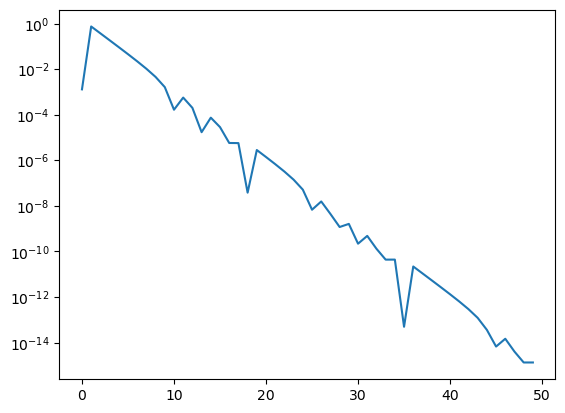

In [33]:
Erreur=abs(sol-x_ref)
semilogy(Erreur,label='Erreur')

Pour calculer le taux de la convergence linéaire on peut interpoler $\ln(|x_n-x_{ref}|)$ par un  polynôme de degré 1 et calculer l'exponentiel de du coefficient directeur de la droite obtenue.

In [34]:
from scipy import interpolate
x=arange(1,51)
f = interpolate.interp1d(x, log(Erreur))
slope=polyfit(x,log(Erreur),1)
print('la taux de la convergence linéaire est', exp(slope[0]))

la taux de la convergence linéaire est 0.5024215742205737


On peut aussi comparer l'erreur  $(|x_n-x_{ref}|)$ avec  $(1/2)^n$ et les représenter à l'échelle semi-logarithmique.  

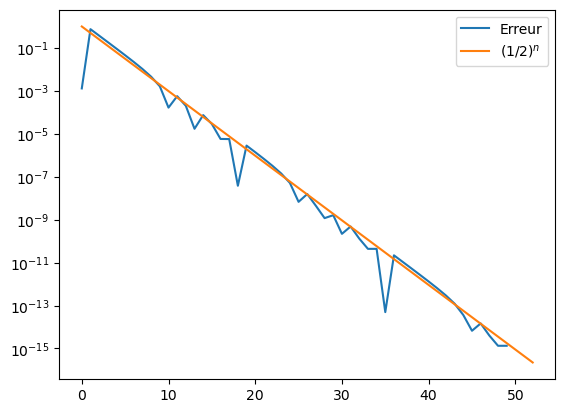

In [35]:
Erreur=abs(sol-x_ref)
semilogy(Erreur,label='Erreur')
c_n=[0.5**n  for n in range(53)]
semilogy(c_n,label='$(1/2)^n$')
legend()

On traca le nombre d'itération en fonction de la tolérence.

Text(0, 0.5, 'nombre d itération')

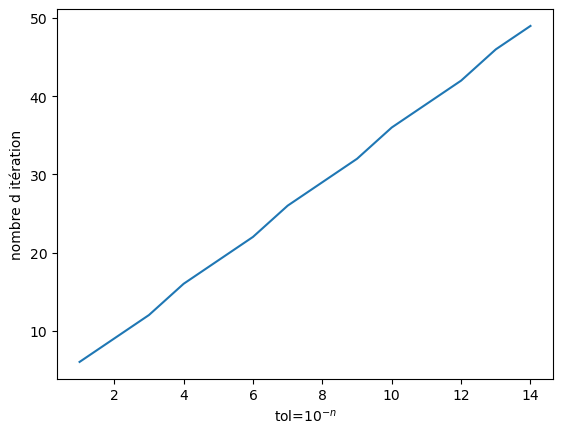

In [36]:
tolerence=[10**-i for i in range (1,15)]
nbr0=[len(dichotomie(g,0,2,tol,1000)) for tol in tolerence]
plot(range (1,15),nbr0)
xlabel('tol=$10^{-n}$')
ylabel('nombre d itération')

In [37]:
x=range (1,15)
f = interpolate.interp1d(x, nbr0)
slope=polyfit(x,nbr0,1)
print('la pente de cette droite est', slope[0])


la pente de cette droite est 3.3296703296703307


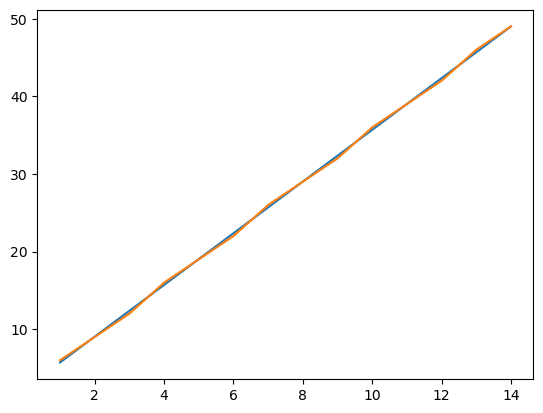

In [38]:
x=range (1,15)
y=slope[1]+slope[0]*x
plot(x,y)
plot(range (1,15),nbr0)
     

Le nombre d'itération nécésaire pour attendre la précision $10^{-n}$ est égal à $\mathcal{O}(n)$.

# Méthode de Newton 


In [39]:
def newton1(f,df,x0,tol,Nmax):
    x=x0
    L=[]
    for i in range(Nmax):
        fx=f(x)
        if abs(x-x_ref)<tol:
            return L
        L.append(x)
        x=x-fx/df(x)     

In [40]:
def dg(u):
    e=0.5
    return 1-e*cos(u)

In [41]:
sol=newton1(g,dg,1,1e-15,100)
sol

[1,
 1.576469352654799,
 1.5002082686066445,
 1.4987017206526596,
 1.4987011335179377]

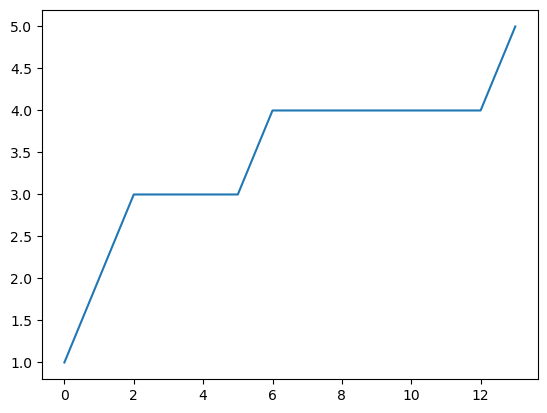

In [42]:
tolerence=[10**-i for i in range (1,15)]
nbr=[len(newton1(g,dg,1,tol,Nmax=100)) for tol in tolerence]
#plot(range (1,15),nbr,'*')
plot(nbr)

# Méthode de la sécante 

In [43]:
def secante(f, x0, x1, tol=1e-15, max_iter=100):
    L=[]
    for i in range(max_iter):
        x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        if abs(x2-x_ref) < tol:
            return L
        L.append(x2)
        x0, x1 = x1, x2
   

In [44]:
sols=secante(g,1,1.5, 1e-15)
sols

[1.4985159451209058, 1.498701071315686, 1.4987011335208282]

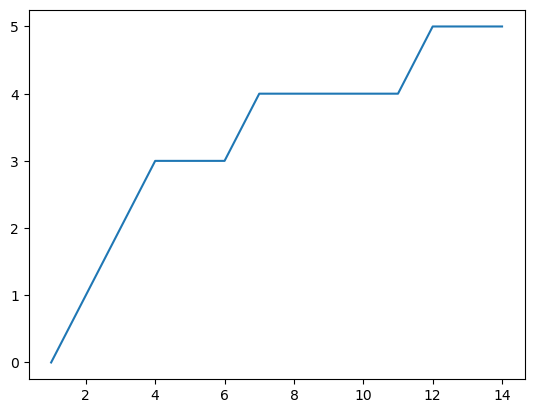

In [51]:
tolerence=[10**-i for i in range (1,15)]
nbr1=[len(secante(g,1,2,tol)) for tol in tolerence]
plot(range (1,15),nbr1)

# Comparaison des vitesses de convergence  

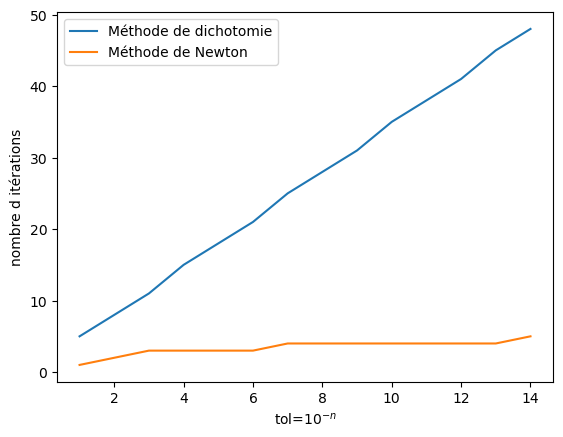

In [92]:
N=15
tolerence=[10**-i for i in range (1,N)]
nbr0=[len(dichotomie(g,1,2,tol,1000)) for tol in tolerence]
plot(range (1,N),nbr0,label='Méthode de dichotomie')
#nbr1=[len(secante(g,1,2,tol)) for tol in tolerence]
nbr=[len(newton1(g,dg,1,tol,Nmax=100)) for tol in tolerence]
plot(range (1,N),nbr,label='Méthode de Newton')
#plot(range (1,N),nbr1,label='Méthode de la sécante')
xlabel('tol=$10^{-n}$')
ylabel('nombre d itérations')
legend()